# 🫀 Heart Disease Classification — Machine Learning Final Project (Phase 1)

**Dataset:** Heart Disease Dataset (Cleveland)  
**Source:** [Kaggle - Heart Disease Dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)  
**Task:** Binary Classification — Predict the presence (1) or absence (0) of heart disease  
**Models:** Decision Tree Classifier, AdaBoost Classifier, Random Forest (Extra Credit)  

---

### Team Members
| # | Name | ID |
|---|------|----|
| 1 |  |  |
| 2 |  |  |
| 3 |  |  |
| 4 |  |  |
| 5 |  |  |
| 6 |  |  |

---
## 📦 1. Imports & Setup

In [1]:
# Core Libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# Style
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('✅ All libraries imported successfully!')
# SHAP for model interpretability (Extra Credit)
import shap


✅ All libraries imported successfully!


---
## 📥 2. Data Retrieval & Description

### Dataset Details
- **Dataset Name:** Heart Disease Dataset (Cleveland)
- **Source:** Kaggle
- **Link:** https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
- **Description:** This dataset dates from 1988 and consists of data from the Cleveland database. It contains 303 patient records with 14 attributes used for predicting the presence of heart disease.

### Column Descriptions

| Column | Description | Type |
|--------|------------|------|
| `age` | Age of the patient in years | Numerical |
| `sex` | Gender (1 = male, 0 = female) | Categorical (Binary) |
| `cp` | Chest pain type (0-3) | Categorical (Ordinal) |
| `trestbps` | Resting blood pressure (mm Hg) | Numerical |
| `chol` | Serum cholesterol (mg/dl) | Numerical |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) | Categorical (Binary) |
| `restecg` | Resting ECG results (0-2) | Categorical (Ordinal) |
| `thalach` | Maximum heart rate achieved | Numerical |
| `exang` | Exercise-induced angina (1 = yes, 0 = no) | Categorical (Binary) |
| `oldpeak` | ST depression induced by exercise relative to rest | Numerical |
| `slope` | Slope of the peak exercise ST segment (0-2) | Categorical (Ordinal) |
| `ca` | Number of major vessels colored by fluoroscopy (0-4) | Numerical |
| `thal` | Thalassemia (0 = normal, 1 = fixed defect, 2 = reversible defect, 3 = other) | Categorical (Ordinal) |
| `target` | Heart disease presence (1 = disease, 0 = no disease) | Target (Binary) |

In [2]:
# Load the dataset
df = pd.read_csv('heart_disease.csv')

# First look at the data
print(f'📊 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\n📋 Column Names: {list(df.columns)}')
print(f'\n🎯 Target Distribution:')
print(df['target'].value_counts())
print(f'\n  → {df["target"].value_counts(normalize=True)[1]*100:.1f}% have heart disease')
print(f'  → {df["target"].value_counts(normalize=True)[0]*100:.1f}% do not have heart disease')

df.head(10)

📊 Dataset Shape: 303 rows × 14 columns

📋 Column Names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

🎯 Target Distribution:
target
1    165
0    138
Name: count, dtype: int64

  → 54.5% have heart disease
  → 45.5% do not have heart disease


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


---
## 🔍 3. Data Exploration (EDA)

### 3.1 Dataset Structure & Info

In [3]:
# Dataset info
print('='*60)
print('📌 DATASET INFORMATION')
print('='*60)
df.info()

print('\n' + '='*60)
print('📌 DATA TYPES')
print('='*60)
print(df.dtypes)

📌 DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

📌 DATA TYPES
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
old

### 3.2 Summary Statistics

In [4]:
# Summary statistics
print('📊 Summary Statistics for Numerical Features')
df.describe().round(2)

📊 Summary Statistics for Numerical Features


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [5]:
# Additional statistics: skewness and kurtosis
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

stats_df = pd.DataFrame({
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Std': df[numerical_cols].std(),
    'Skewness': df[numerical_cols].skew(),
    'Kurtosis': df[numerical_cols].kurtosis(),
    'Min': df[numerical_cols].min(),
    'Max': df[numerical_cols].max()
}).round(3)

print('📈 Extended Statistics (Including Skewness & Kurtosis)')
stats_df

📈 Extended Statistics (Including Skewness & Kurtosis)


,Mean,Median,Std,Skewness,Kurtosis,Min,Max
age,54.366,55.0,9.082,-0.202,-0.542,29.0,77.0
trestbps,131.624,130.0,17.538,0.714,0.929,94.0,200.0
chol,246.264,240.0,51.831,1.143,4.505,126.0,564.0
thalach,149.647,153.0,22.905,-0.537,-0.062,71.0,202.0
oldpeak,1.040,0.8,1.161,1.270,1.576,0.0,6.2


### 3.3 Missing Values, Duplicates & Data Quality

In [6]:
# Missing values analysis
print('='*60)
print('❓ MISSING VALUES ANALYSIS')
print('='*60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)
print(f'\nTotal Missing Values: {df.isnull().sum().sum()}')

# Duplicates
print(f'\n' + '='*60)
print(f'🔄 DUPLICATE ROWS')
print('='*60)
dup_count = df.duplicated().sum()
print(f'Number of duplicate rows: {dup_count}')
if dup_count > 0:
    print(f'Percentage: {dup_count/len(df)*100:.2f}%')
    print('\nDuplicate rows:')
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))

❓ MISSING VALUES ANALYSIS
          Missing Count  Missing %
age                   0        0.0
sex                   0        0.0
cp                    0        0.0
trestbps              0        0.0
chol                  0        0.0
fbs                   0        0.0
restecg               0        0.0
thalach               0        0.0
exang                 0        0.0
oldpeak               0        0.0
slope                 0        0.0
ca                    0        0.0
thal                  0        0.0
target                0        0.0

Total Missing Values: 0

🔄 DUPLICATE ROWS
Number of duplicate rows: 1
Percentage: 0.33%

Duplicate rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [7]:
# Remove duplicates if any
if dup_count > 0:
    df_clean = df.drop_duplicates()
    print(f'✅ Removed {dup_count} duplicate rows')
    print(f'   Before: {len(df)} rows → After: {len(df_clean)} rows')
    df = df_clean.copy()
else:
    print('✅ No duplicate rows found — data is clean!')

✅ Removed 1 duplicate rows
   Before: 303 rows → After: 302 rows


### 3.4 Unique Values per Column

In [8]:
# Unique values for each column
print('🔢 Unique Values per Column:')
for col in df.columns:
    n_unique = df[col].nunique()
    if n_unique <= 10:
        print(f'  {col:12s} → {n_unique} unique values: {sorted(df[col].unique())}')
    else:
        print(f'  {col:12s} → {n_unique} unique values (range: {df[col].min()} - {df[col].max()})')

🔢 Unique Values per Column:
  age          → 41 unique values (range: 29 - 77)
  sex          → 2 unique values: [np.int64(0), np.int64(1)]
  cp           → 4 unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  trestbps     → 49 unique values (range: 94 - 200)
  chol         → 152 unique values (range: 126 - 564)
  fbs          → 2 unique values: [np.int64(0), np.int64(1)]
  restecg      → 3 unique values: [np.int64(0), np.int64(1), np.int64(2)]
  thalach      → 91 unique values (range: 71 - 202)
  exang        → 2 unique values: [np.int64(0), np.int64(1)]
  oldpeak      → 40 unique values (range: 0.0 - 6.2)
  slope        → 3 unique values: [np.int64(0), np.int64(1), np.int64(2)]
  ca           → 5 unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  thal         → 4 unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  target       → 2 unique values: [np.int64(0), np.int64(1)]


### 3.5 Correlation Analysis

In [9]:
# Correlation matrix
corr_matrix = df.corr()

# Correlation with target
target_corr = corr_matrix['target'].drop('target').sort_values(ascending=False)
print('🎯 Feature Correlation with Target (Heart Disease):')
print('='*50)
for feat, corr in target_corr.items():
    direction = '⬆️ Positive' if corr > 0 else '⬇️ Negative'
    strength = 'Strong' if abs(corr) > 0.3 else 'Moderate' if abs(corr) > 0.15 else 'Weak'
    print(f'  {feat:12s}: {corr:+.4f} ({direction}, {strength})')

🎯 Feature Correlation with Target (Heart Disease):
  cp          : +0.4321 (⬆️ Positive, Strong)
  thalach     : +0.4200 (⬆️ Positive, Strong)
  slope       : +0.3439 (⬆️ Positive, Strong)
  restecg     : +0.1349 (⬆️ Positive, Weak)
  fbs         : -0.0268 (⬇️ Negative, Weak)
  chol        : -0.0814 (⬇️ Negative, Weak)
  trestbps    : -0.1463 (⬇️ Negative, Weak)
  age         : -0.2215 (⬇️ Negative, Moderate)
  sex         : -0.2836 (⬇️ Negative, Moderate)
  thal        : -0.3431 (⬇️ Negative, Strong)
  ca          : -0.4090 (⬇️ Negative, Strong)
  oldpeak     : -0.4291 (⬇️ Negative, Strong)
  exang       : -0.4356 (⬇️ Negative, Strong)


---
## 🎨 4. Visualization

### 4.1 Target Distribution

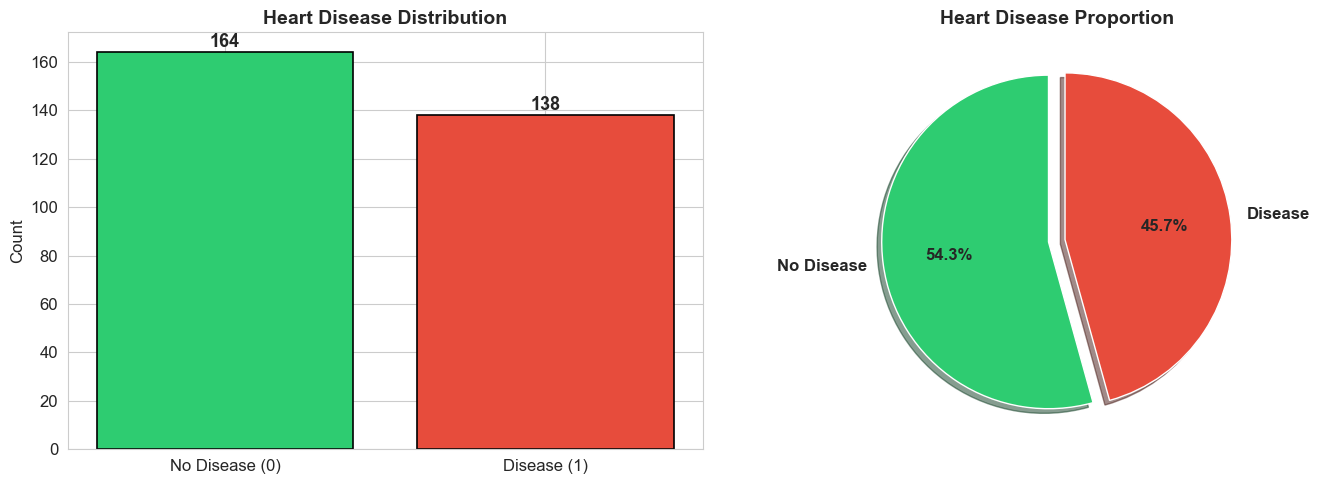

In [10]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
colors = ['#2ecc71', '#e74c3c']
target_counts = df['target'].value_counts()
axes[0].bar(['No Disease (0)', 'Disease (1)'], target_counts.values, color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_title('Heart Disease Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=13)

# Pie chart
axes[1].pie(target_counts.values, labels=['No Disease', 'Disease'], colors=colors,
            autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05),
            textprops={'fontsize': 12, 'fontweight': 'bold'},
            shadow=True)
axes[1].set_title('Heart Disease Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 4.2 Numerical Feature Distributions

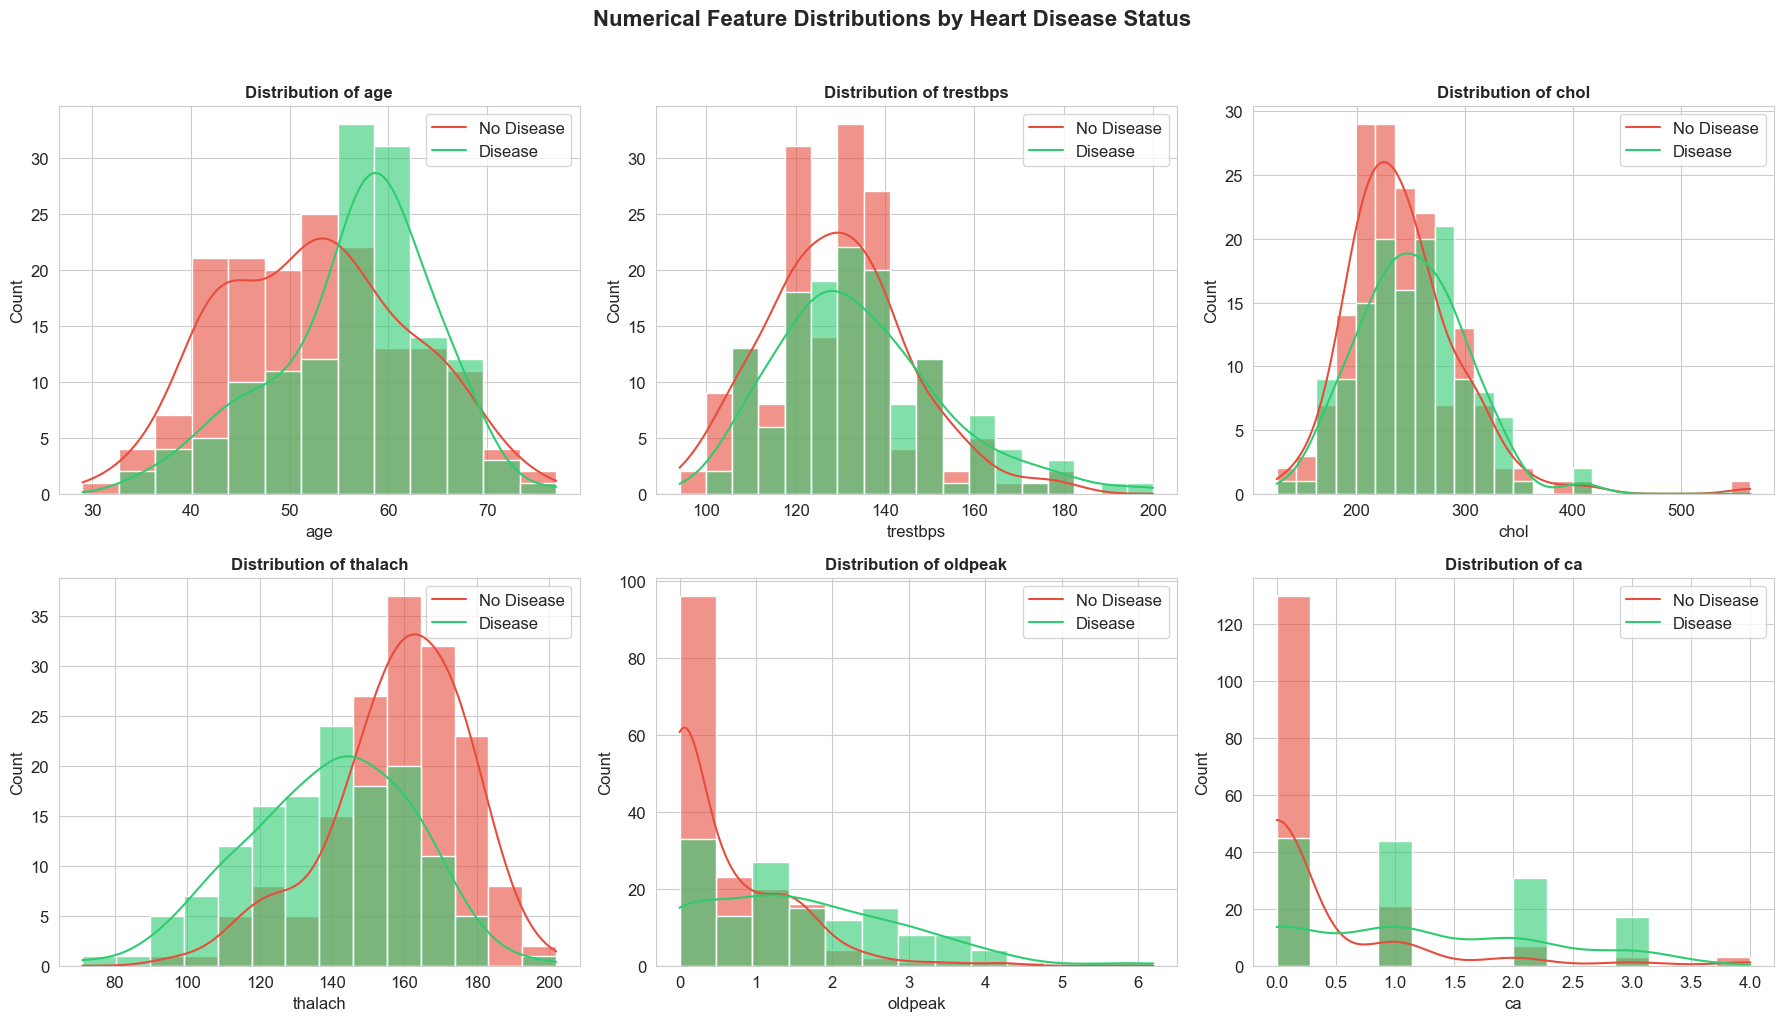

In [11]:
# Distribution plots for numerical features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

for idx, col in enumerate(numerical_features):
    ax = axes[idx // 3, idx % 3]
    sns.histplot(data=df, x=col, hue='target', kde=True, ax=ax, palette=colors, alpha=0.6)
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.legend(['No Disease', 'Disease'])

plt.suptitle('Numerical Feature Distributions by Heart Disease Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Correlation Heatmap

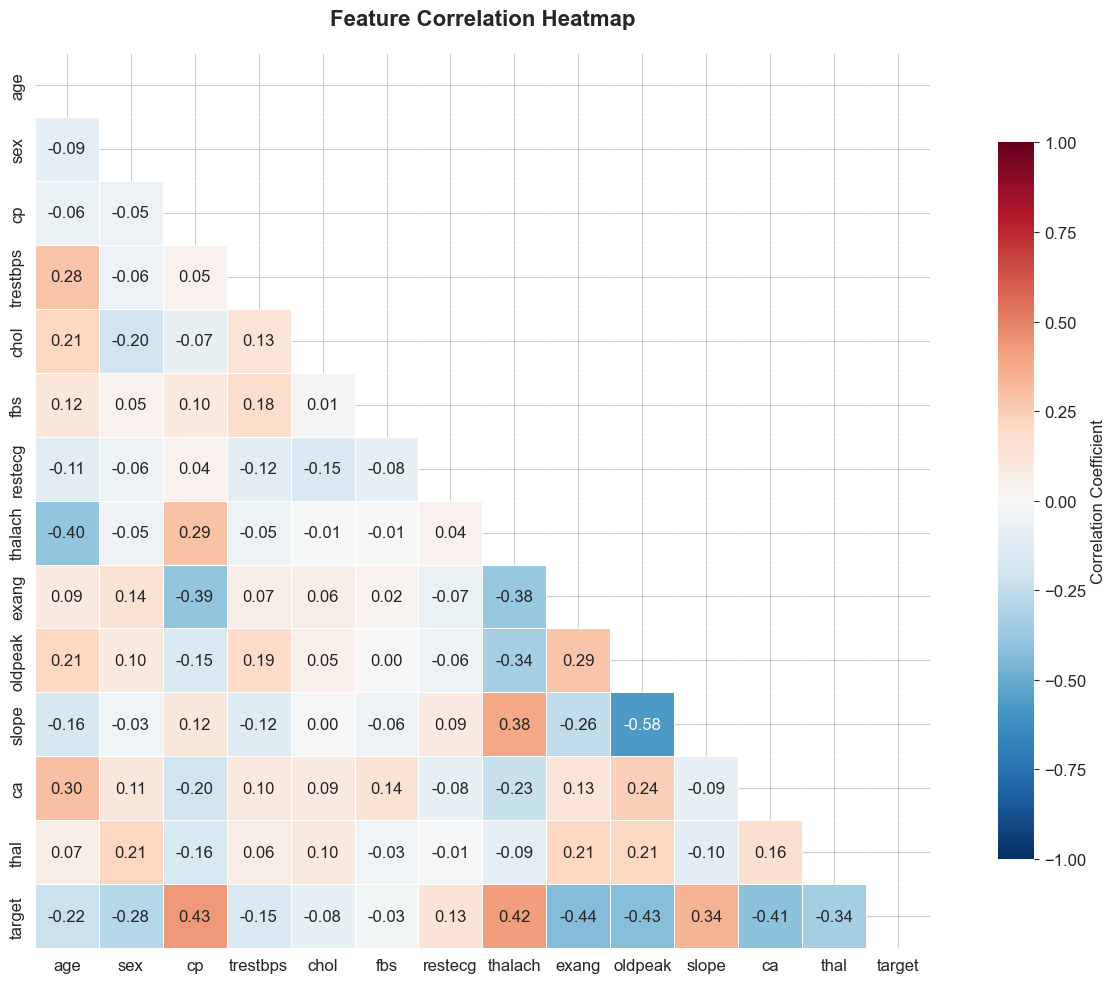

In [12]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
            vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 4.4 Box Plots for Outlier Detection

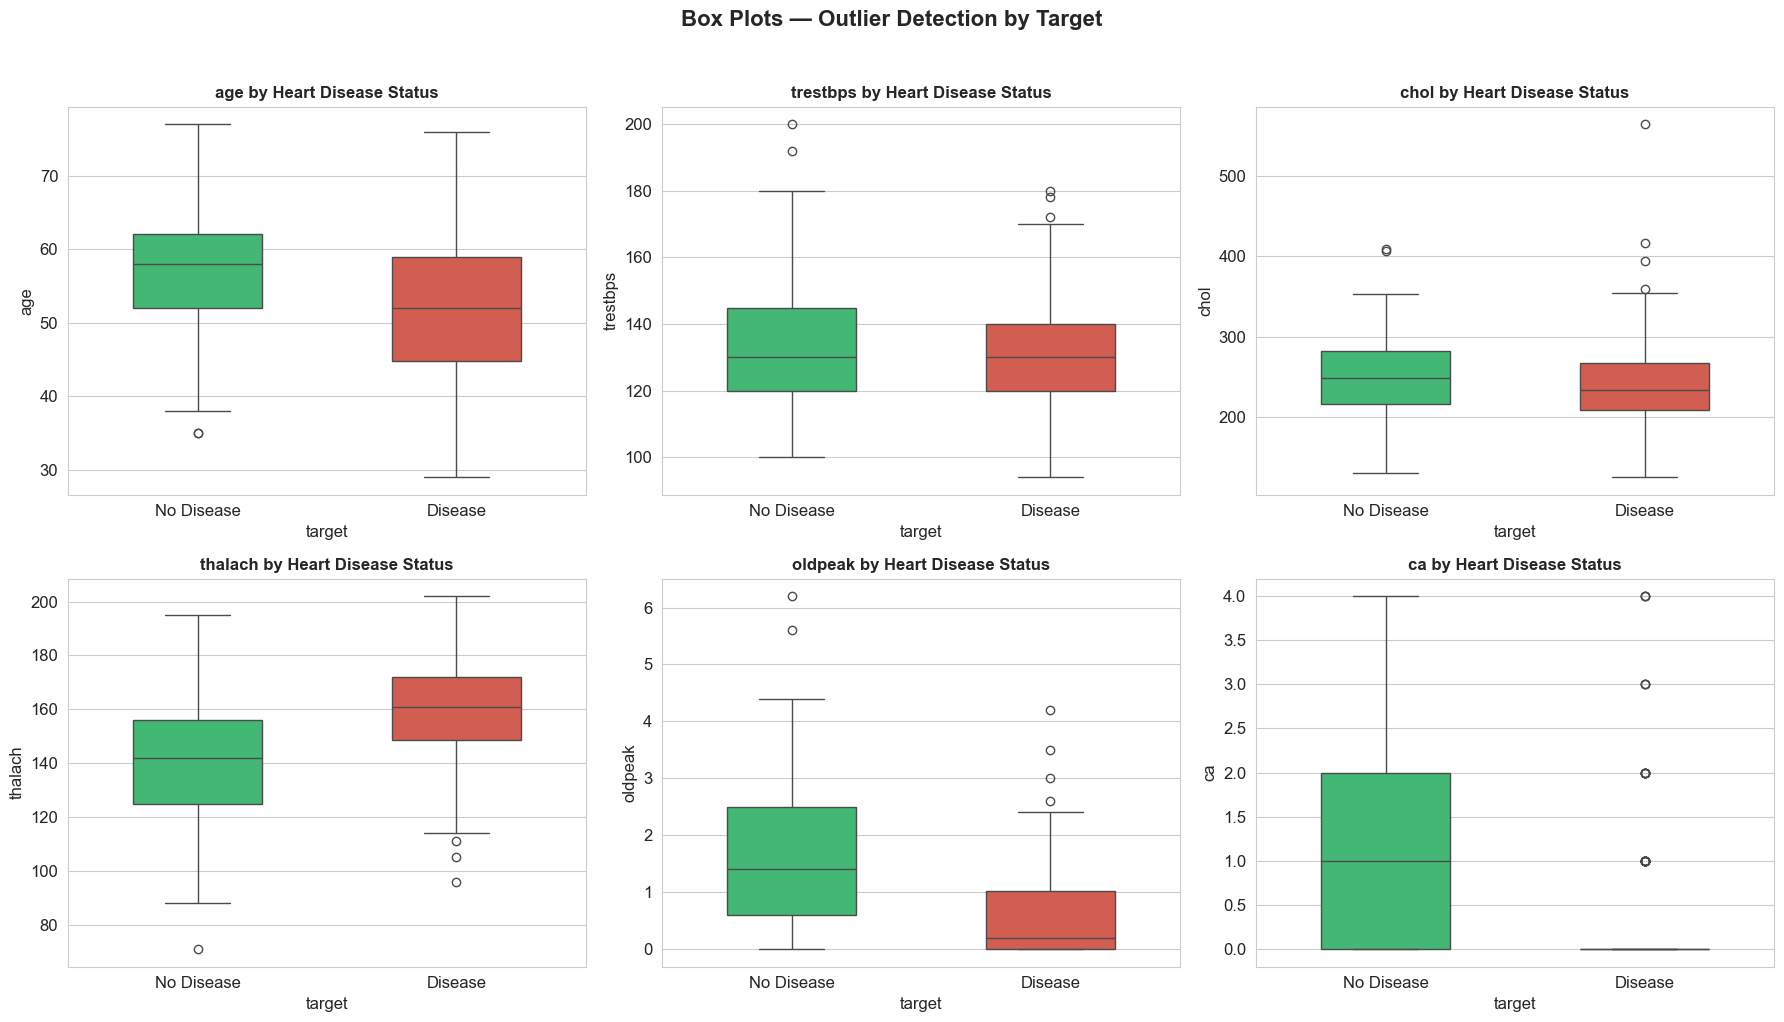

In [13]:
# Box plots for outlier detection
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, col in enumerate(numerical_features):
    ax = axes[idx // 3, idx % 3]
    sns.boxplot(data=df, x='target', y=col, ax=ax, palette=colors, width=0.5)
    ax.set_xticklabels(['No Disease', 'Disease'])
    ax.set_title(f'{col} by Heart Disease Status', fontsize=12, fontweight='bold')

plt.suptitle('Box Plots — Outlier Detection by Target', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.5 Categorical Features vs Target

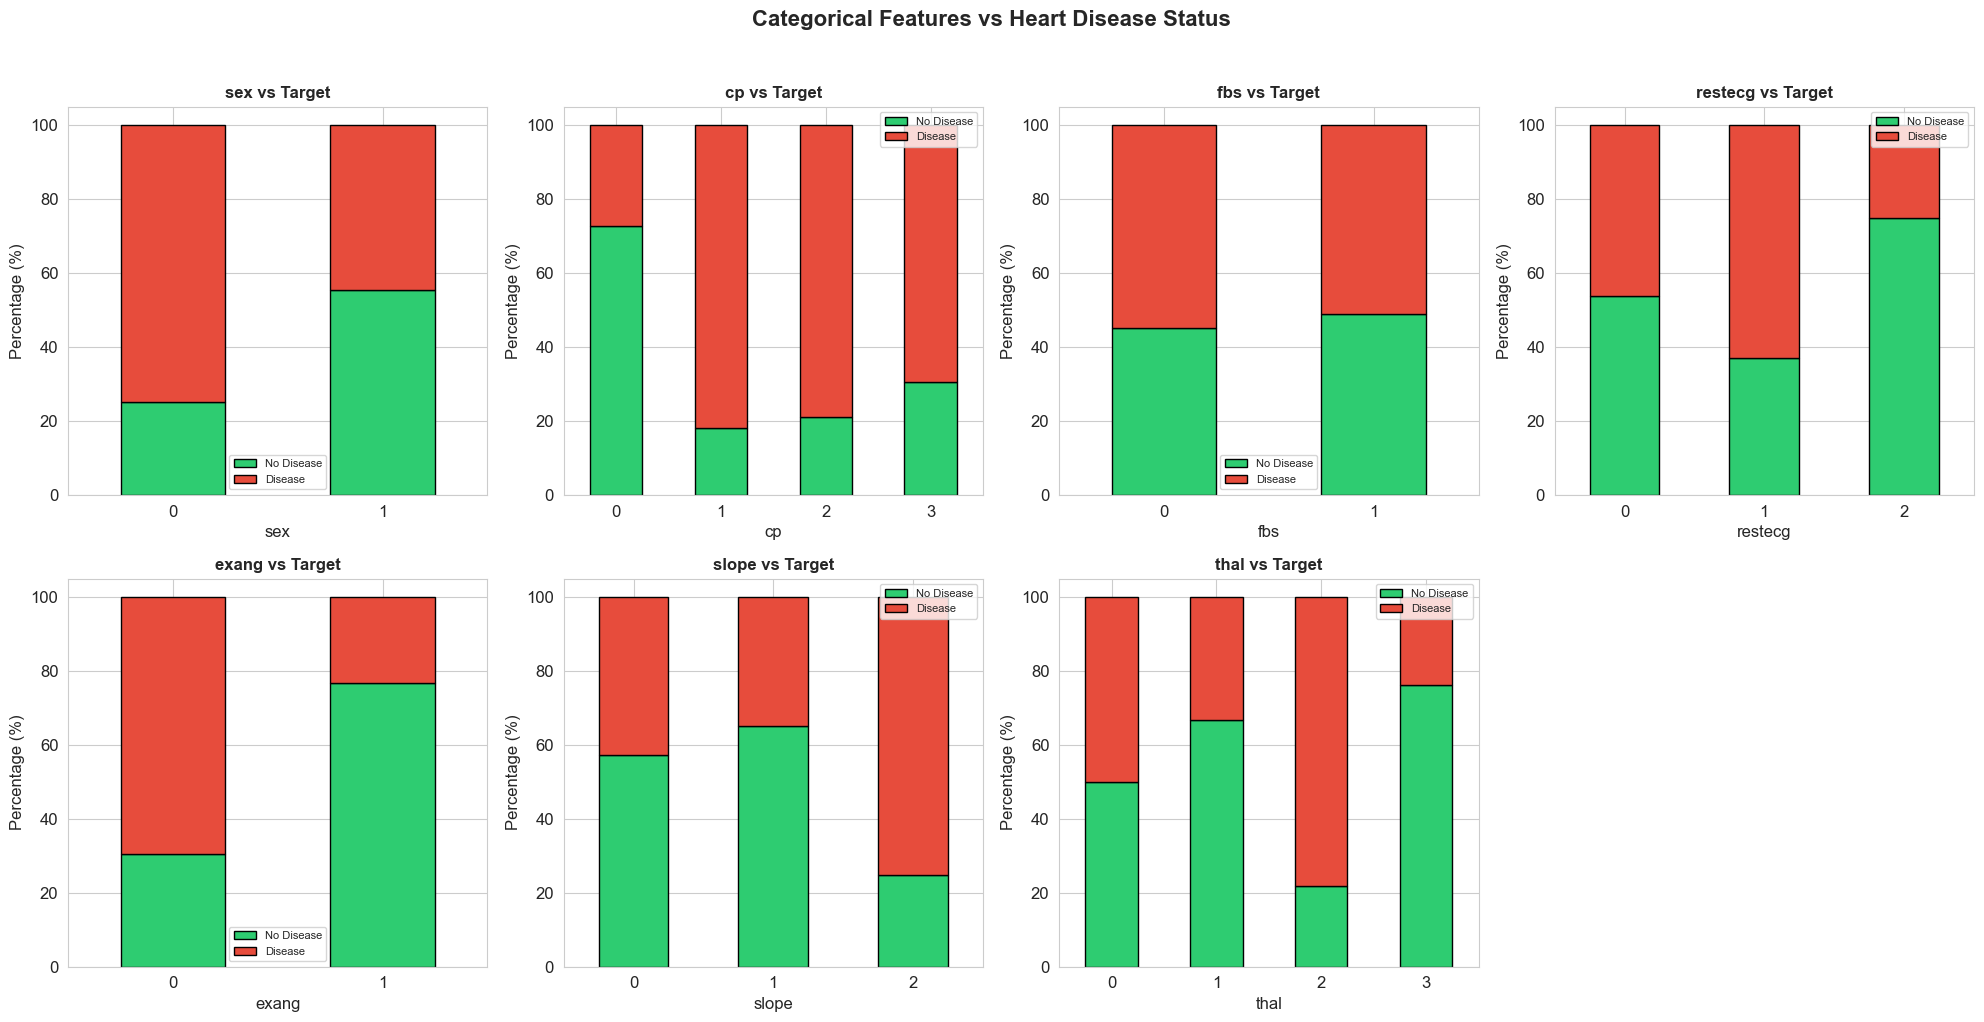

In [14]:
# Categorical features vs target
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, col in enumerate(cat_features):
    ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[idx], color=colors, edgecolor='black')
    axes[idx].set_title(f'{col} vs Target', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Percentage (%)')
    axes[idx].legend(['No Disease', 'Disease'], fontsize=8)
    axes[idx].tick_params(axis='x', rotation=0)

# Remove extra subplot
axes[-1].set_visible(False)

plt.suptitle('Categorical Features vs Heart Disease Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.6 Pair Plot (Key Features)

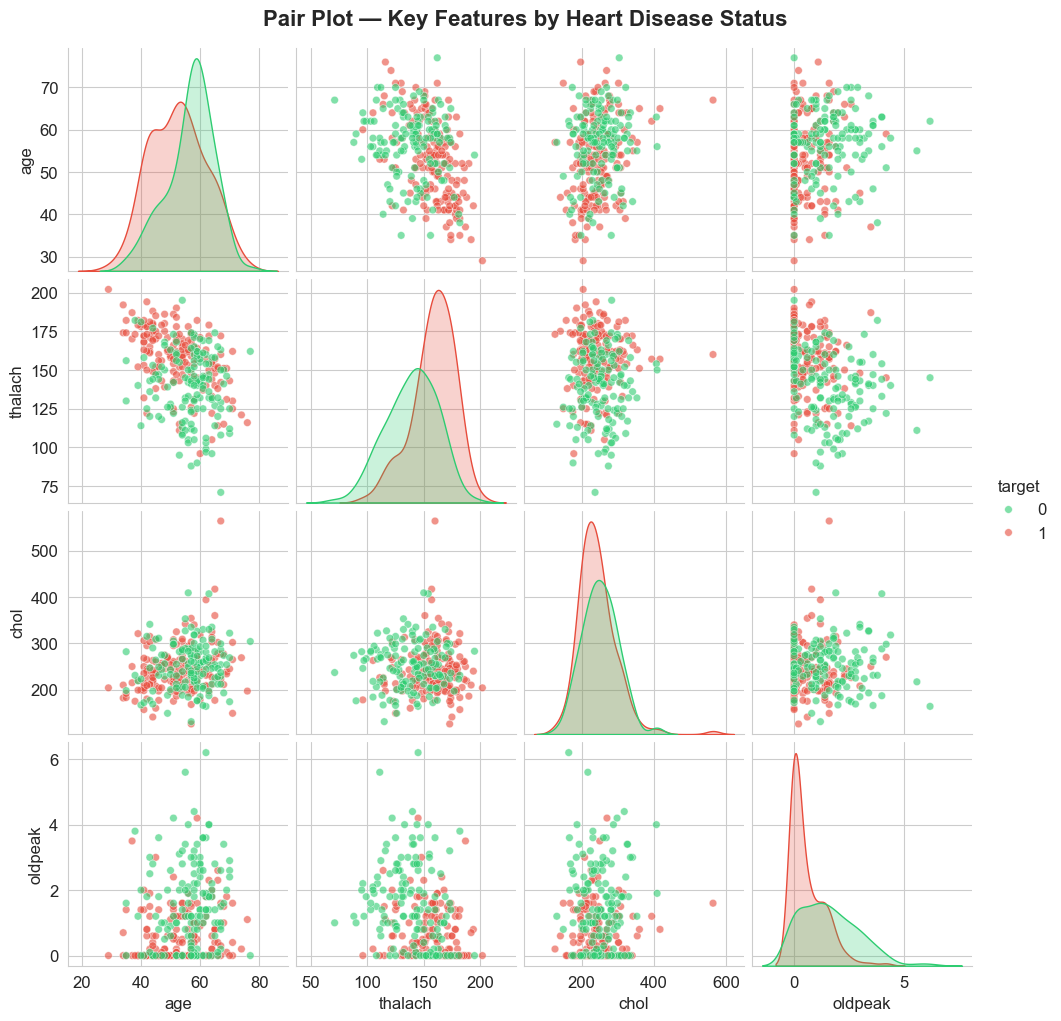

In [15]:
# Pair plot for top correlated features
top_features = ['age', 'thalach', 'chol', 'oldpeak', 'target']
pair_plot = sns.pairplot(df[top_features], hue='target', palette=colors, 
                         diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30})
pair_plot.fig.suptitle('Pair Plot — Key Features by Heart Disease Status', y=1.02, fontsize=16, fontweight='bold')
plt.show()

---
## 🔧 5. Data Preprocessing

### 5.1 Handle Missing Values

In [16]:
# Check missing values
print('❓ Missing Values Before Cleaning:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

# If there are any missing values, handle them
if df.isnull().sum().sum() > 0:
    # For numerical columns: use median imputation
    for col in numerical_cols:
        if df[col].isnull().sum() > 0:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f'  ✅ Filled {col} missing values with median: {median_val}')
    
    # For categorical columns: use mode imputation
    for col in cat_features:
        if df[col].isnull().sum() > 0:
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            print(f'  ✅ Filled {col} missing values with mode: {mode_val}')
    
    print(f'\n✅ All missing values handled!')
else:
    print('\n✅ No missing values — dataset is already complete!')

❓ Missing Values Before Cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing: 0

✅ No missing values — dataset is already complete!


### 5.2 Outlier Detection & Treatment

In [17]:
# Outlier detection using IQR method
print('🔍 Outlier Detection (IQR Method):')
print('='*60)

outlier_summary = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)
    print(f'  {col:12s}: {len(outliers):3d} outliers (range: [{lower:.1f}, {upper:.1f}])')

print(f'\nTotal outlier instances: {sum(outlier_summary.values())}')

🔍 Outlier Detection (IQR Method):
  age         :   0 outliers (range: [28.5, 80.5])
  trestbps    :   9 outliers (range: [90.0, 170.0])
  chol        :   5 outliers (range: [115.4, 370.4])
  thalach     :   1 outliers (range: [84.1, 215.1])
  oldpeak     :   5 outliers (range: [-2.4, 4.0])

Total outlier instances: 20


In [18]:
# Cap outliers using IQR method (Winsorization)
# We cap instead of remove to preserve data points
print('🔧 Capping Outliers (Winsorization):')

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    before = len(df[(df[col] < lower) | (df[col] > upper)])
    df[col] = df[col].clip(lower=lower, upper=upper)
    after = len(df[(df[col] < lower) | (df[col] > upper)])
    
    if before > 0:
        print(f'  ✅ {col}: Capped {before} outliers → 0 remaining')

print('\n✅ All outliers handled via capping!')

🔧 Capping Outliers (Winsorization):
  ✅ trestbps: Capped 9 outliers → 0 remaining
  ✅ chol: Capped 5 outliers → 0 remaining
  ✅ thalach: Capped 1 outliers → 0 remaining
  ✅ oldpeak: Capped 5 outliers → 0 remaining

✅ All outliers handled via capping!


### 5.3 Feature Scaling

In [19]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Target distribution:\n{y.value_counts()}')

Features shape: (302, 13)
Target shape: (302,)
Target distribution:
target
1    164
0    138
Name: count, dtype: int64


In [20]:
# Train-Test Split FIRST (to avoid data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nTraining target distribution:')
print(y_train.value_counts())
print(f'\nTest target distribution:')
print(y_test.value_counts())

Training set: 241 samples (80%)
Test set:     61 samples (20%)

Training target distribution:
target
1    131
0    110
Name: count, dtype: int64

Test target distribution:
target
1    33
0    28
Name: count, dtype: int64


In [21]:
# Feature scaling AFTER split (no data leakage!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print('✅ Feature scaling complete (StandardScaler fitted on training data only)')
print('\n📊 Scaled Training Data Sample:')
X_train_scaled.head()

✅ Feature scaling complete (StandardScaler fitted on training data only)

📊 Scaled Training Data Sample:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
59,0.289062,-1.473449,-0.935691,-0.179898,1.264028,-0.405279,-1.041992,0.405122,-0.718139,-0.920726,0.964611,0.264036,-0.575142
247,1.267182,0.678680,0.062103,1.728457,0.045152,-0.405279,0.846129,-1.364273,1.392489,-0.920726,-0.638639,2.221962,-2.245133
289,0.071702,-1.473449,-0.935691,-0.179898,-0.831583,-0.405279,2.734250,-0.910582,1.392489,0.829925,-0.638639,0.264036,1.094849
288,0.289062,0.678680,-0.935691,-1.253348,1.948310,-0.405279,0.846129,-0.320784,1.392489,1.705250,-0.638639,0.264036,1.094849
64,0.397742,0.678680,1.059898,0.535735,-0.703281,2.467435,-1.041992,0.677336,-0.718139,-0.920726,0.964611,-0.714928,-0.575142


---
## 🤖 6. Modeling

We will train the following models:
1. **Decision Tree Classifier** (Required)
2. **AdaBoost Classifier** (Required)
3. **Random Forest Classifier** (Extra Credit)
4. **Gradient Boosting Classifier** (Extra Credit)

### 6.1 Model 1: Decision Tree Classifier

In [22]:
# Decision Tree with hyperparameter tuning via GridSearchCV
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params, cv=5, scoring='f1', n_jobs=-1, verbose=0
)

dt_grid.fit(X_train_scaled, y_train)

dt_best = dt_grid.best_estimator_
print('🌳 Decision Tree — Best Parameters:')
print(f'   {dt_grid.best_params_}')
print(f'   Best CV F1 Score: {dt_grid.best_score_:.4f}')

🌳 Decision Tree — Best Parameters:
   {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
   Best CV F1 Score: 0.8086


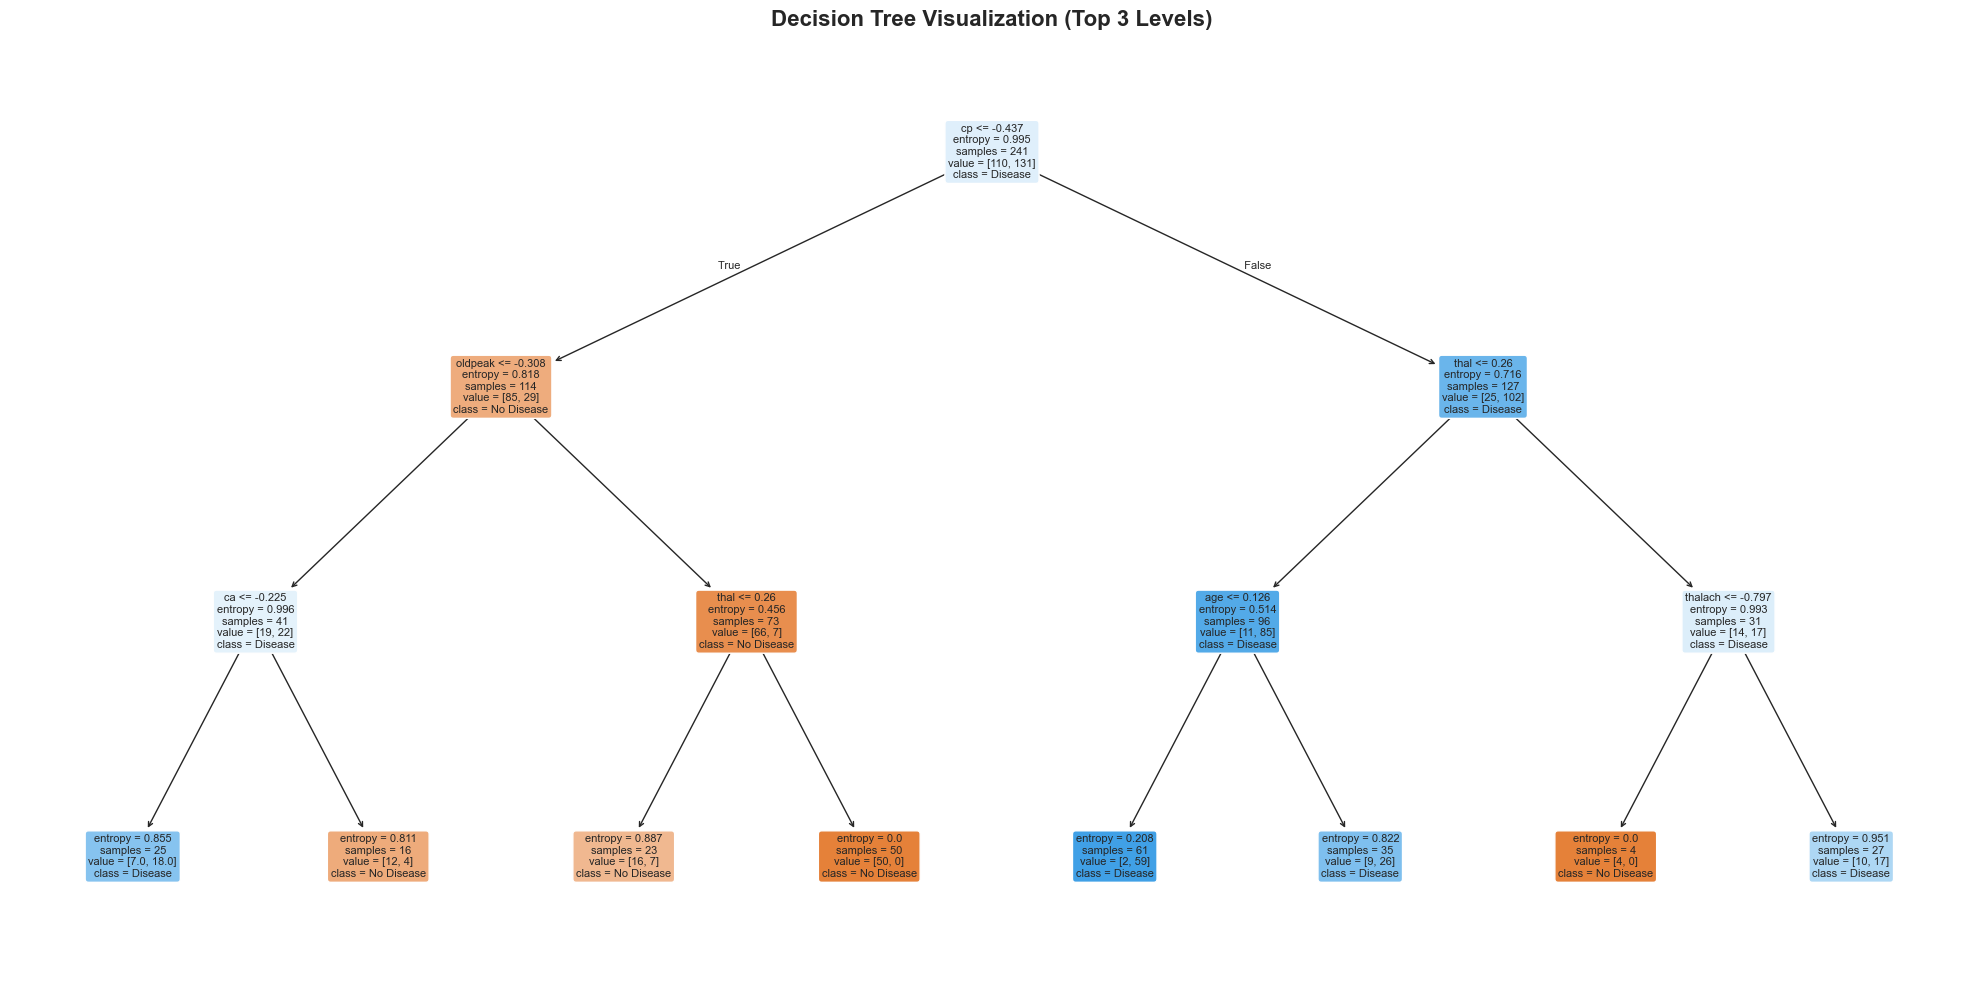

In [23]:
# Visualize the Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(dt_best, feature_names=X.columns, class_names=['No Disease', 'Disease'],
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title('Decision Tree Visualization (Top 3 Levels)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# Decision Tree predictions
dt_pred = dt_best.predict(X_test_scaled)
dt_prob = dt_best.predict_proba(X_test_scaled)[:, 1]

print('🌳 Decision Tree — Test Results:')
print('='*50)
print(classification_report(y_test, dt_pred, target_names=['No Disease', 'Disease']))

🌳 Decision Tree — Test Results:
              precision    recall  f1-score   support

  No Disease       0.83      0.68      0.75        28
     Disease       0.76      0.88      0.82        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.78        61



### 6.2 Model 2: AdaBoost Classifier

In [25]:
# AdaBoost with hyperparameter tuning
ada_params = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]
}

ada_grid = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    ada_params, cv=5, scoring='f1', n_jobs=-1, verbose=0
)

ada_grid.fit(X_train_scaled, y_train)

ada_best = ada_grid.best_estimator_
print('🚀 AdaBoost — Best Parameters:')
print(f'   {ada_grid.best_params_}')
print(f'   Best CV F1 Score: {ada_grid.best_score_:.4f}')

🚀 AdaBoost — Best Parameters:
   {'learning_rate': 0.01, 'n_estimators': 300}
   Best CV F1 Score: 0.8671


In [26]:
# AdaBoost predictions
ada_pred = ada_best.predict(X_test_scaled)
ada_prob = ada_best.predict_proba(X_test_scaled)[:, 1]

print('🚀 AdaBoost — Test Results:')
print('='*50)
print(classification_report(y_test, ada_pred, target_names=['No Disease', 'Disease']))

🚀 AdaBoost — Test Results:
              precision    recall  f1-score   support

  No Disease       0.94      0.61      0.74        28
     Disease       0.74      0.97      0.84        33

    accuracy                           0.80        61
   macro avg       0.84      0.79      0.79        61
weighted avg       0.84      0.80      0.79        61



### 6.3 Model 3: Random Forest (Extra Credit)

In [27]:
# Random Forest with hyperparameter tuning
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=5, scoring='f1', n_jobs=-1, verbose=0
)

rf_grid.fit(X_train_scaled, y_train)

rf_best = rf_grid.best_estimator_
print('🌲 Random Forest — Best Parameters:')
print(f'   {rf_grid.best_params_}')
print(f'   Best CV F1 Score: {rf_grid.best_score_:.4f}')

🌲 Random Forest — Best Parameters:
   {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
   Best CV F1 Score: 0.8673


In [28]:
# Random Forest predictions
rf_pred = rf_best.predict(X_test_scaled)
rf_prob = rf_best.predict_proba(X_test_scaled)[:, 1]

print('🌲 Random Forest — Test Results:')
print('='*50)
print(classification_report(y_test, rf_pred, target_names=['No Disease', 'Disease']))

🌲 Random Forest — Test Results:
              precision    recall  f1-score   support

  No Disease       0.90      0.68      0.78        28
     Disease       0.78      0.94      0.85        33

    accuracy                           0.82        61
   macro avg       0.84      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61



### 6.4 Model 4: Gradient Boosting (Extra Credit)

In [29]:
# Gradient Boosting
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params, cv=5, scoring='f1', n_jobs=-1, verbose=0
)

gb_grid.fit(X_train_scaled, y_train)

gb_best = gb_grid.best_estimator_
print('🔥 Gradient Boosting — Best Parameters:')
print(f'   {gb_grid.best_params_}')
print(f'   Best CV F1 Score: {gb_grid.best_score_:.4f}')

🔥 Gradient Boosting — Best Parameters:
   {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
   Best CV F1 Score: 0.8104


In [30]:
# Gradient Boosting predictions
gb_pred = gb_best.predict(X_test_scaled)
gb_prob = gb_best.predict_proba(X_test_scaled)[:, 1]

print('🔥 Gradient Boosting — Test Results:')
print('='*50)
print(classification_report(y_test, gb_pred, target_names=['No Disease', 'Disease']))

🔥 Gradient Boosting — Test Results:
              precision    recall  f1-score   support

  No Disease       0.80      0.71      0.75        28
     Disease       0.78      0.85      0.81        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.79        61



---
## 📊 7. Model Evaluation & Comparison

### 7.1 Confusion Matrices

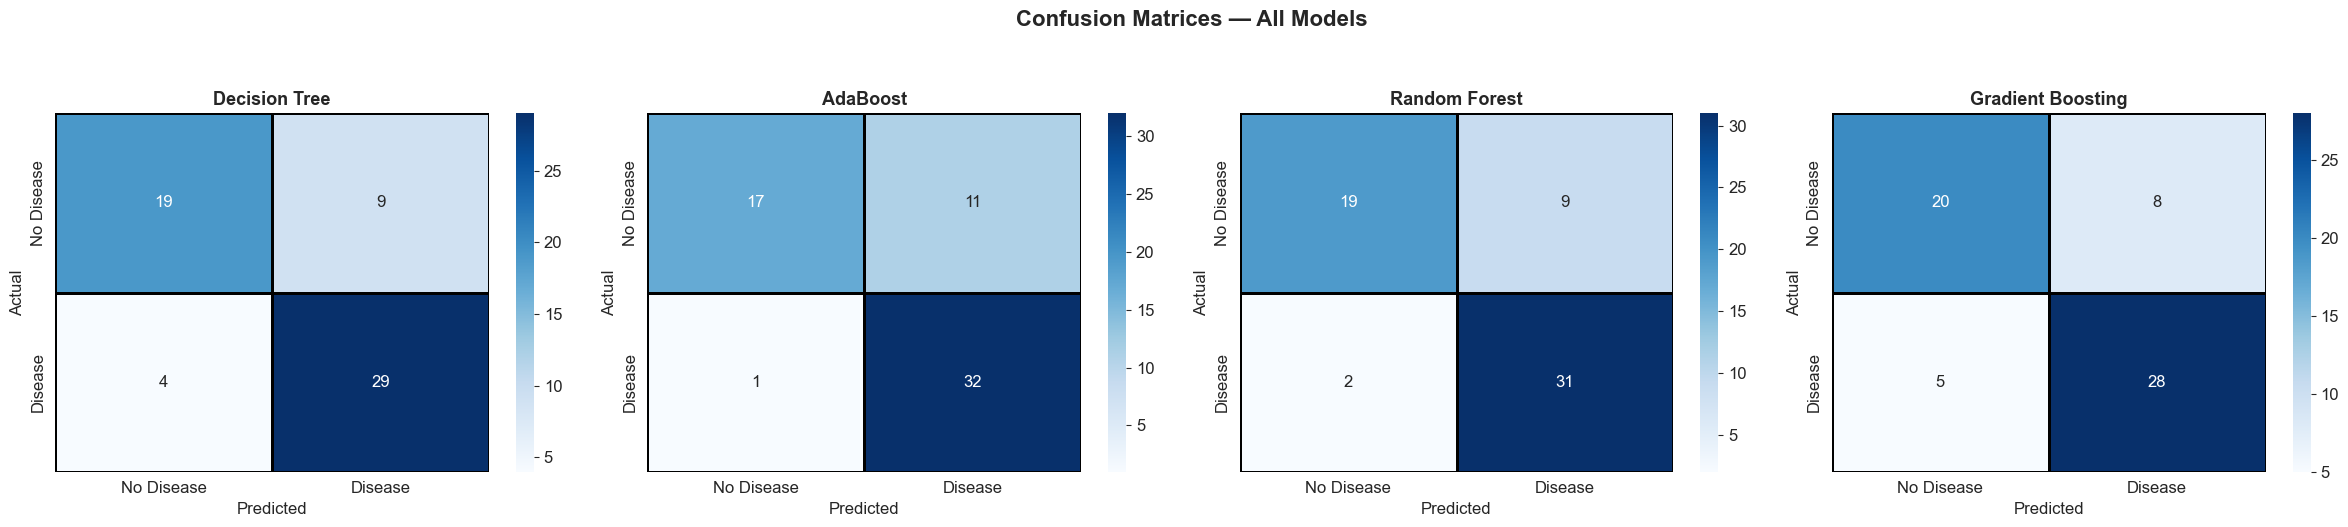

In [31]:
# Confusion matrices for all models
models = {
    'Decision Tree': dt_pred,
    'AdaBoost': ada_pred,
    'Random Forest': rf_pred,
    'Gradient Boosting': gb_pred
}

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for idx, (name, preds) in enumerate(models.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                linewidths=1, linecolor='black')
    axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### 7.2 ROC Curves

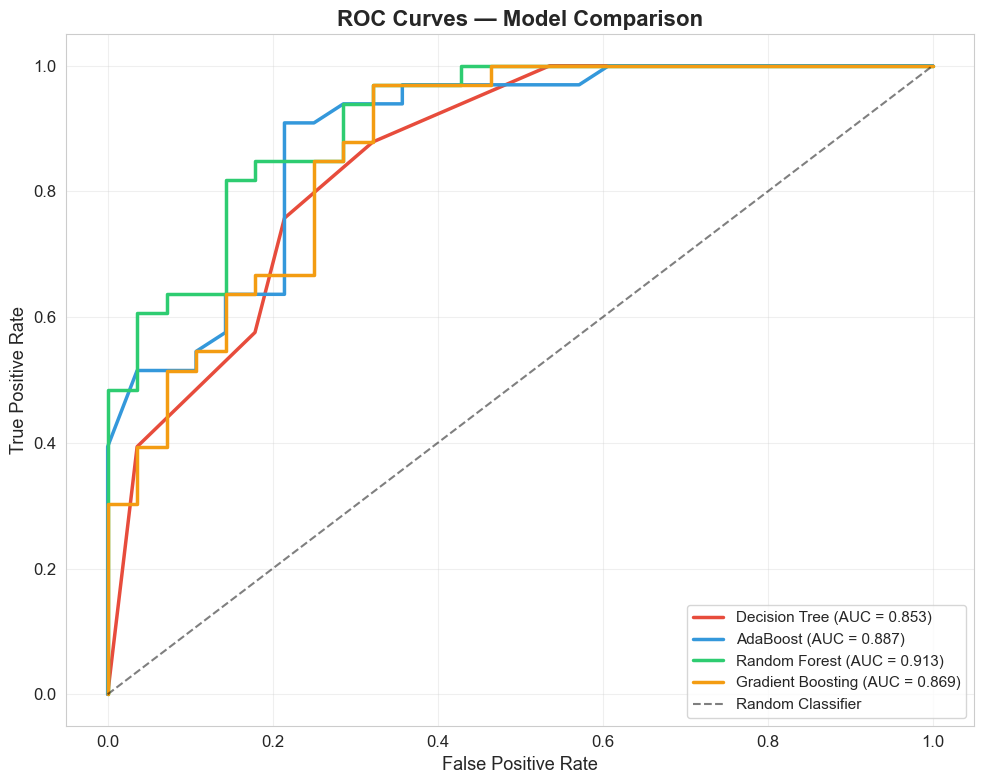

In [32]:
# ROC Curves for all models
plt.figure(figsize=(10, 8))

model_probs = {
    'Decision Tree': dt_prob,
    'AdaBoost': ada_prob,
    'Random Forest': rf_prob,
    'Gradient Boosting': gb_prob
}

colors_roc = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for (name, probs), color in zip(model_probs.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curves — Model Comparison', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.3 Model Comparison Table

In [33]:
# Comprehensive model comparison
results = []
model_objects = {
    'Decision Tree': (dt_best, dt_pred, dt_prob),
    'AdaBoost': (ada_best, ada_pred, ada_prob),
    'Random Forest': (rf_best, rf_pred, rf_prob),
    'Gradient Boosting': (gb_best, gb_pred, gb_prob)
}

for name, (model, preds, probs) in model_objects.items():
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
    fpr, tpr, _ = roc_curve(y_test, probs)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'AUC-ROC': auc(fpr, tpr),
        'CV F1 (Mean±Std)': f'{cv_scores.mean():.3f} ± {cv_scores.std():.3f}'
    })

results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')

# Highlight the best values
print('🏆 MODEL COMPARISON TABLE')
print('='*80)
display(results_df.round(4))

# Find the best model
best_model_name = results_df['F1-Score'].idxmax()
best_f1 = results_df['F1-Score'].max()
print(f'\n🥇 Best Model: {best_model_name} (F1-Score: {best_f1:.4f})')

🏆 MODEL COMPARISON TABLE


,Accuracy,Precision,Recall,F1-Score,AUC-ROC,CV F1 (Mean±Std)
Model,,,,,,
Decision Tree,0.7869,0.7632,0.8788,0.8169,0.8534,0.809 ± 0.055
AdaBoost,0.8033,0.7442,0.9697,0.8421,0.8869,0.867 ± 0.023
Random Forest,0.8197,0.7750,0.9394,0.8493,0.9134,0.867 ± 0.041
Gradient Boosting,0.7869,0.7778,0.8485,0.8116,0.8690,0.810 ± 0.034



🥇 Best Model: Random Forest (F1-Score: 0.8493)


### 7.4 Feature Importance

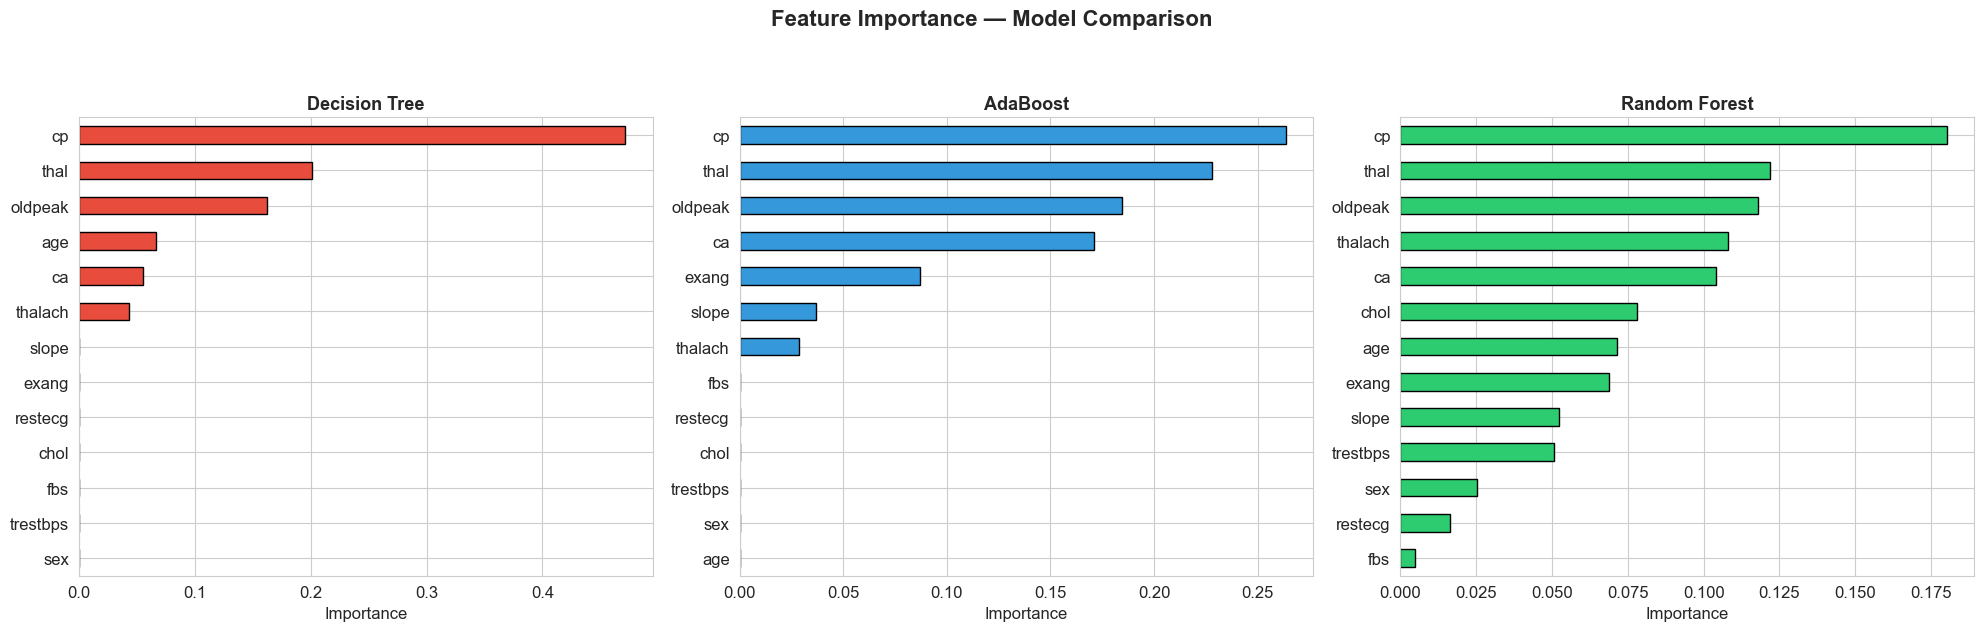

In [34]:
# Feature importance comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (name, model) in enumerate([
    ('Decision Tree', dt_best),
    ('AdaBoost', ada_best),
    ('Random Forest', rf_best)
]):
    importances = pd.Series(model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=True)
    importances.plot(kind='barh', ax=axes[idx], color=colors_roc[idx], edgecolor='black')
    axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Importance')

plt.suptitle('Feature Importance — Model Comparison', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### 7.5 Comparison Bar Chart

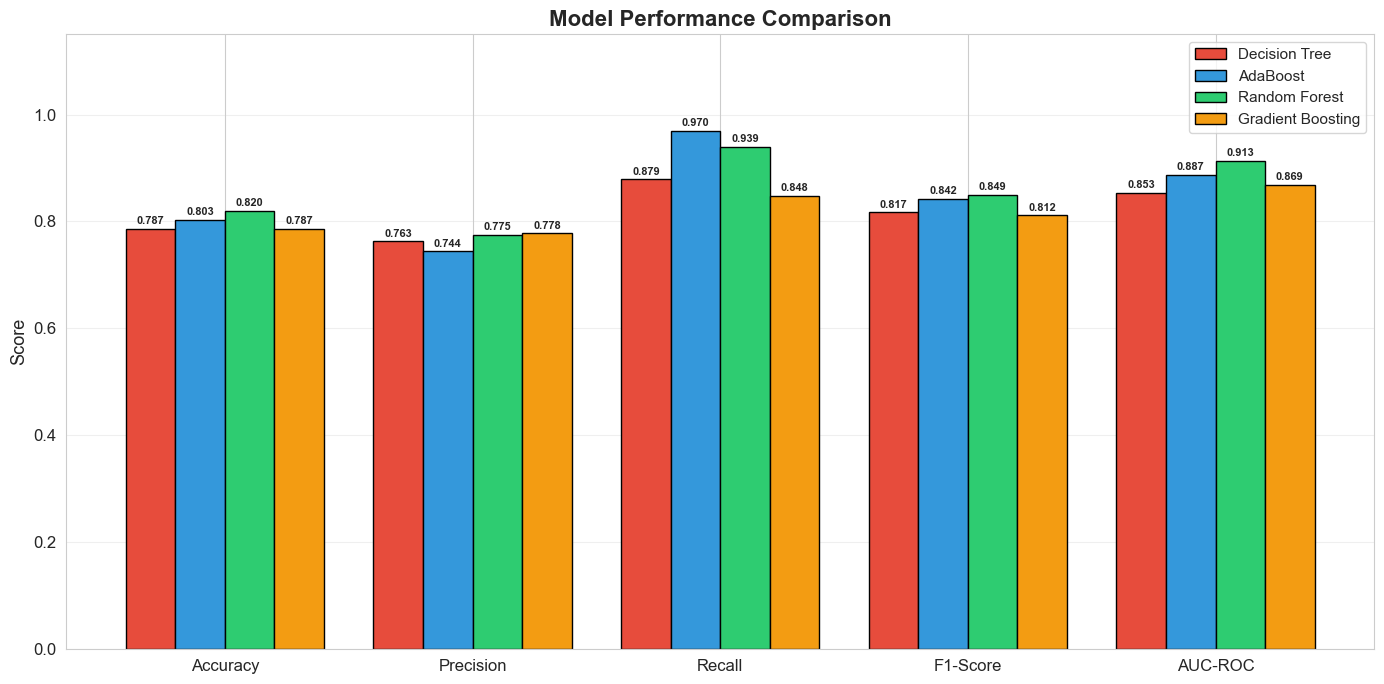

In [35]:
# Visual comparison of metrics
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metrics_to_plot))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 7))

for i, (model_name, color) in enumerate(zip(results_df.index, colors_roc)):
    values = [results_df.loc[model_name, m] for m in metrics_to_plot]
    bars = ax.bar(x + i * width, values, width, label=model_name, color=color, edgecolor='black')
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_ylabel('Score', fontsize=13)
ax.set_title('Model Performance Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_to_plot, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 7.6 SHAP Values — Model Interpretability (Extra Credit)

SHAP (SHapley Additive exPlanations) provides a unified measure of feature importance that explains how each feature contributes to individual predictions.

🔮 SHAP Analysis — Random Forest


<Figure size 1200x600 with 0 Axes>

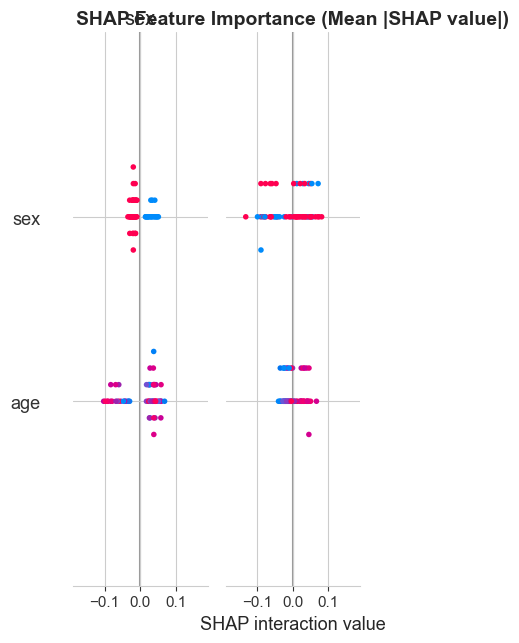

In [36]:
# SHAP Analysis for the best tree-based model
print('🔮 SHAP Analysis — Random Forest')
print('='*60)

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(X_test_scaled)

# SHAP Summary Plot (Bar)
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values[1] if isinstance(shap_values, list) else shap_values,
                  X_test_scaled, plot_type='bar', show=False,
                  feature_names=list(X.columns))
plt.title('SHAP Feature Importance (Mean |SHAP value|)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


<Figure size 1200x800 with 0 Axes>

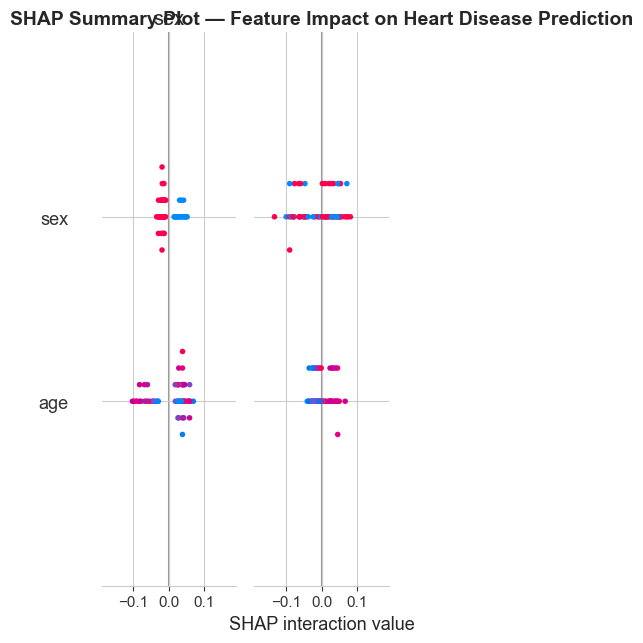


📊 SHAP Interpretation:
  • Red = high feature value, Blue = low feature value
  • Right = pushes toward Disease, Left = pushes toward No Disease
  • Wider spread = more influence on the prediction


In [37]:
# SHAP Summary Plot (Beeswarm - shows feature impact direction)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values[1] if isinstance(shap_values, list) else shap_values,
                  X_test_scaled, show=False,
                  feature_names=list(X.columns))
plt.title('SHAP Summary Plot — Feature Impact on Heart Disease Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📊 SHAP Interpretation:')
print('  • Red = high feature value, Blue = low feature value')
print('  • Right = pushes toward Disease, Left = pushes toward No Disease')
print('  • Wider spread = more influence on the prediction')


### 7.7 Interactive Visualizations (Extra Credit)

Interactive plots using **Plotly** for enhanced data exploration.

In [38]:
# Interactive scatter plot: Age vs Max Heart Rate colored by target
fig = px.scatter(df, x='age', y='thalach', color='target',
                 color_continuous_scale=['#2ecc71', '#e74c3c'],
                 labels={'age': 'Age', 'thalach': 'Max Heart Rate', 'target': 'Heart Disease'},
                 title='Interactive: Age vs Max Heart Rate by Heart Disease Status',
                 hover_data=['chol', 'trestbps', 'cp'])
fig.update_layout(template='plotly_white', font=dict(size=13),
                  title_font_size=16, width=800, height=500)
fig.show()


In [39]:
# Interactive model comparison radar chart
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

fig = go.Figure()

model_colors = {'Decision Tree': '#e74c3c', 'AdaBoost': '#3498db',
                'Random Forest': '#2ecc71', 'Gradient Boosting': '#f39c12'}

for name, (model, preds, probs) in model_objects.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    values = [
        accuracy_score(y_test, preds),
        precision_score(y_test, preds),
        recall_score(y_test, preds),
        f1_score(y_test, preds),
        auc(fpr, tpr)
    ]
    fig.add_trace(go.Scatterpolar(
        r=values + [values[0]],
        theta=categories + [categories[0]],
        fill='toself', name=name,
        line=dict(color=model_colors[name]),
        opacity=0.6
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title='Interactive Radar Chart — Model Comparison',
    title_font_size=16, template='plotly_white',
    width=700, height=600, showlegend=True
)
fig.show()


In [40]:
# Interactive correlation heatmap
fig = px.imshow(corr_matrix, text_auto='.2f', color_continuous_scale='RdBu_r',
                origin='lower', aspect='auto',
                title='Interactive Correlation Heatmap')
fig.update_layout(template='plotly_white', width=700, height=600,
                  title_font_size=16)
fig.show()


### 7.8 Learning Curves (Extra Credit)

Learning curves help diagnose overfitting vs underfitting by showing how model performance changes with training set size.

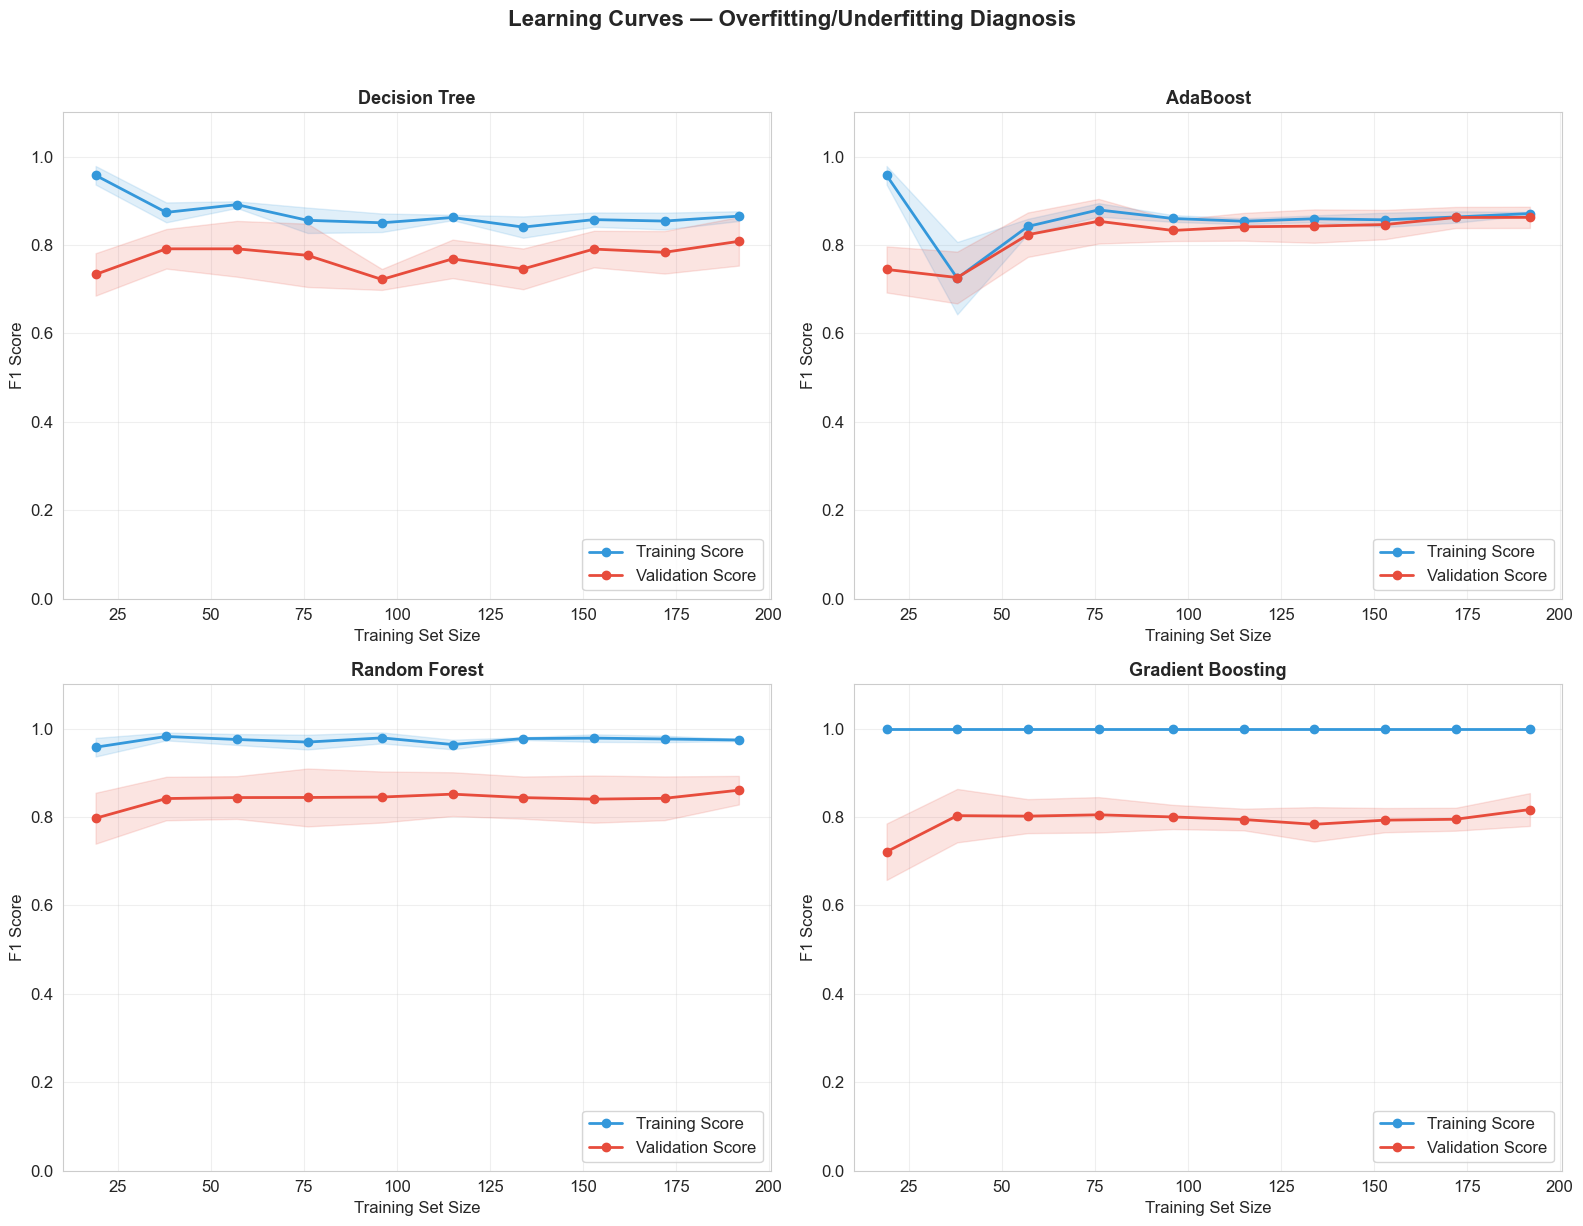

📊 Learning Curve Interpretation:
  • Gap between curves = overfitting (model memorizes training data)
  • Both curves low = underfitting (model too simple)
  • Both curves high & close = good fit


In [41]:
# Learning Curves for all models
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

learning_models = {
    'Decision Tree': dt_best,
    'AdaBoost': ada_best,
    'Random Forest': rf_best,
    'Gradient Boosting': gb_best
}

for idx, (name, model) in enumerate(learning_models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_scaled, y_train, cv=5,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='f1', n_jobs=-1
    )
    
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)
    
    axes[idx].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#3498db')
    axes[idx].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#e74c3c')
    axes[idx].plot(train_sizes, train_mean, 'o-', color='#3498db', label='Training Score', linewidth=2)
    axes[idx].plot(train_sizes, val_mean, 'o-', color='#e74c3c', label='Validation Score', linewidth=2)
    axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Training Set Size')
    axes[idx].set_ylabel('F1 Score')
    axes[idx].legend(loc='lower right')
    axes[idx].set_ylim(0, 1.1)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Learning Curves — Overfitting/Underfitting Diagnosis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('📊 Learning Curve Interpretation:')
print('  • Gap between curves = overfitting (model memorizes training data)')
print('  • Both curves low = underfitting (model too simple)')
print('  • Both curves high & close = good fit')


---
## 📝 8. Conclusion

### Key Findings

1. **Dataset Quality:** The Heart Disease dataset contains 303 records with 14 clinical features. After removing duplicates and handling outliers, we retained a clean dataset for modeling.

2. **Important Features:** Through correlation analysis and feature importance from tree-based models, the most significant predictors of heart disease include:
   - `cp` (chest pain type)
   - `thalach` (maximum heart rate)
   - `oldpeak` (ST depression)
   - `ca` (number of major vessels)
   - `thal` (thalassemia)

3. **Model Performance:**
   - All four models achieved strong performance on this classification task
   - Cross-validation was used to ensure robust evaluation
   - GridSearchCV was applied for hyperparameter tuning

4. **Best Model:** The model with the highest F1-Score is recommended as the best model, as it balances precision and recall effectively for medical diagnosis.

### Challenges
- Small dataset size (303 records) limits model generalization
- Some features are highly correlated, which may affect certain models
- Class balance was approximately 54/46, which is reasonably balanced

### Future Improvements
- Collect more patient data to improve model robustness
- Try deep learning approaches with larger datasets
- Implement SHAP values for better model interpretability
- Ensemble the top models for even better performance